<a href="https://colab.research.google.com/github/Harshit10880/Chat-logger/blob/main/gro_siri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [ ]:
data = pd.read_csv("grocery_chain_data.csv")

In [ ]:
data.head(5)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,8/26/2023,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2/13/2024,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,11/23/2023,Bakery,Onions,4,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,1/13/2025,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,10/13/2023,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22


In [ ]:
print(data.isnull().sum())
print(data.duplicated().sum())



customer_id          0
store_name          25
transaction_date     0
aisle                0
product_name         0
quantity             0
unit_price           0
total_amount         0
discount_amount      0
final_amount         0
loyalty_points       0
dtype: int64
0


# Check which store sells the highest (by total final_amount)

In [ ]:
store_sales = data.groupby('store_name')['final_amount'].sum().sort_values(ascending=False)
print("\nTop Stores by Total Sales:")
print(store_sales)


Top Stores by Total Sales:
store_name
GreenGrocer Plaza     9880.76
SuperSave Central     9859.89
City Fresh Store      9788.70
MegaMart Westside     9295.79
Corner Grocery        9285.50
ValuePlus Market      8661.24
FreshMart Downtown    8206.87
QuickStop Market      8182.89
FamilyFood Express    7719.49
Name: final_amount, dtype: float64


In [ ]:
top_store = store_sales.idxmax()
print(f"\nHighest selling store: {top_store}")


Highest selling store: GreenGrocer Plaza


In [ ]:
data['store_name'] = data['store_name'].fillna(top_store)

In [ ]:
print(data.isnull().sum())


customer_id         0
store_name          0
transaction_date    0
aisle               0
product_name        0
quantity            0
unit_price          0
total_amount        0
discount_amount     0
final_amount        0
loyalty_points      0
dtype: int64


# Visulization

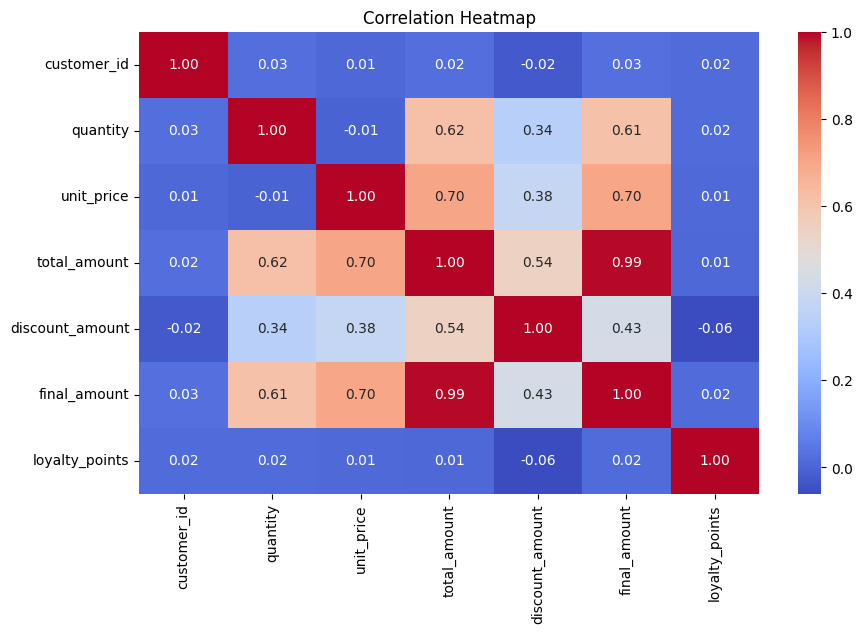

In [ ]:
data['transaction_date'] = pd.to_datetime(data['transaction_date'])

plt.figure(figsize=(10,6))
numeric_df = data.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()


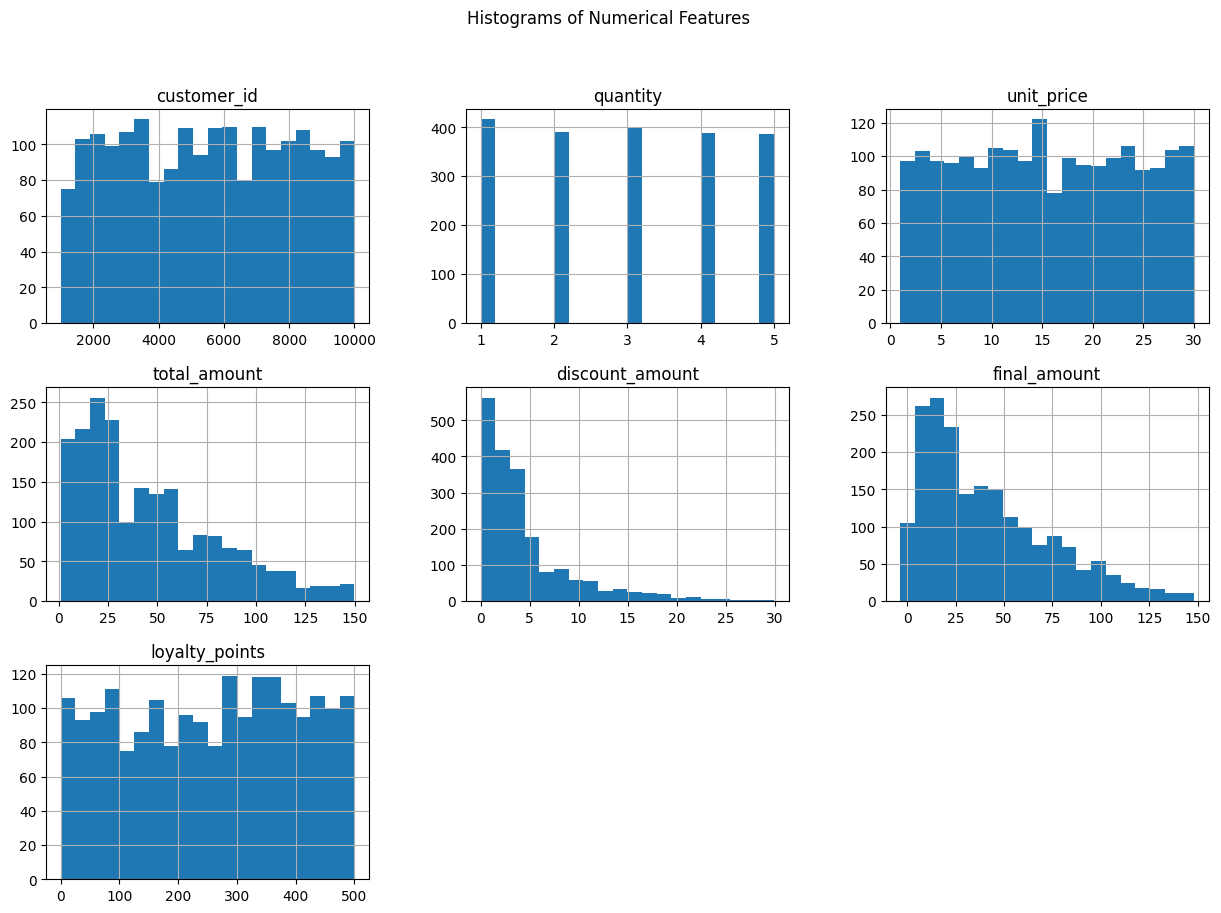

In [ ]:
numeric_df.hist(
    figsize=(15,10),
    bins=20
)

plt.suptitle("Histograms of Numerical Features")
plt.show()

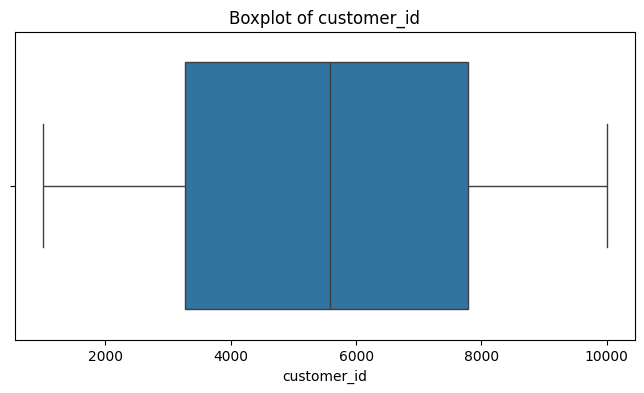

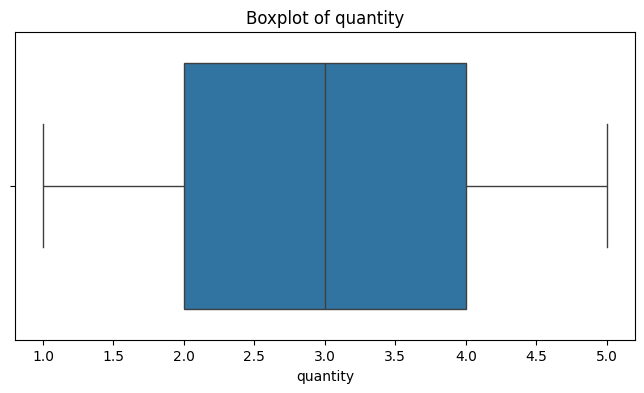

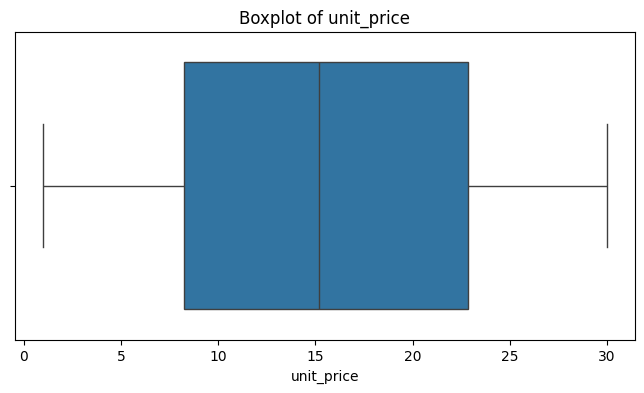

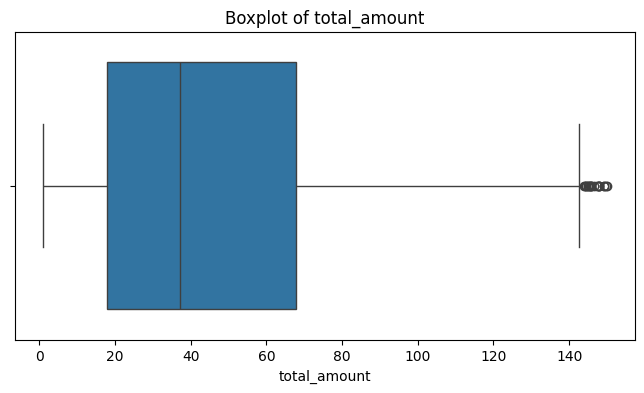

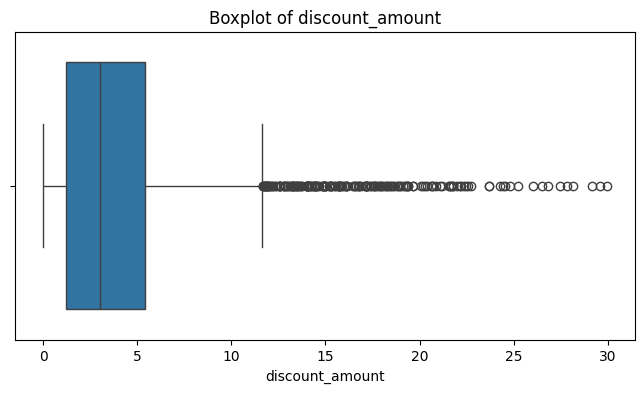

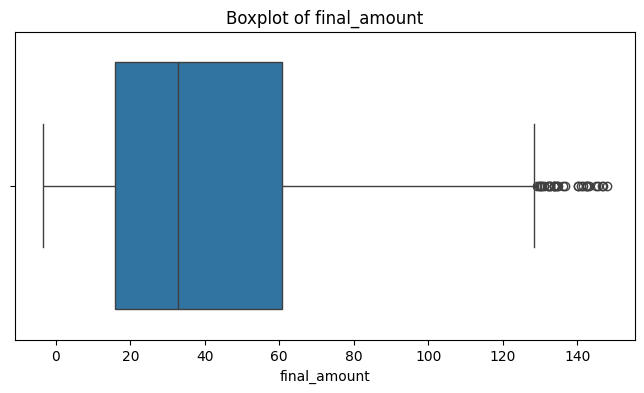

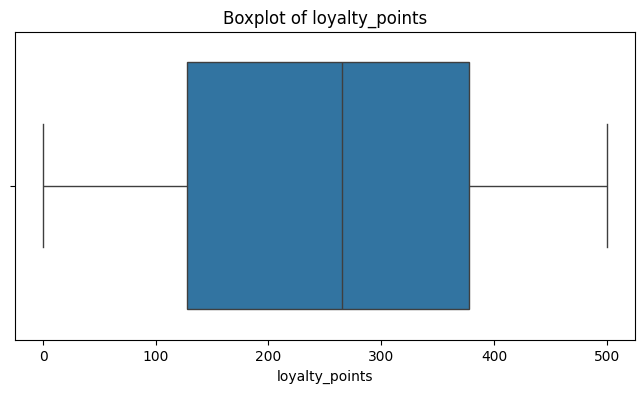

In [ ]:
for col in numeric_df.columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=data[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

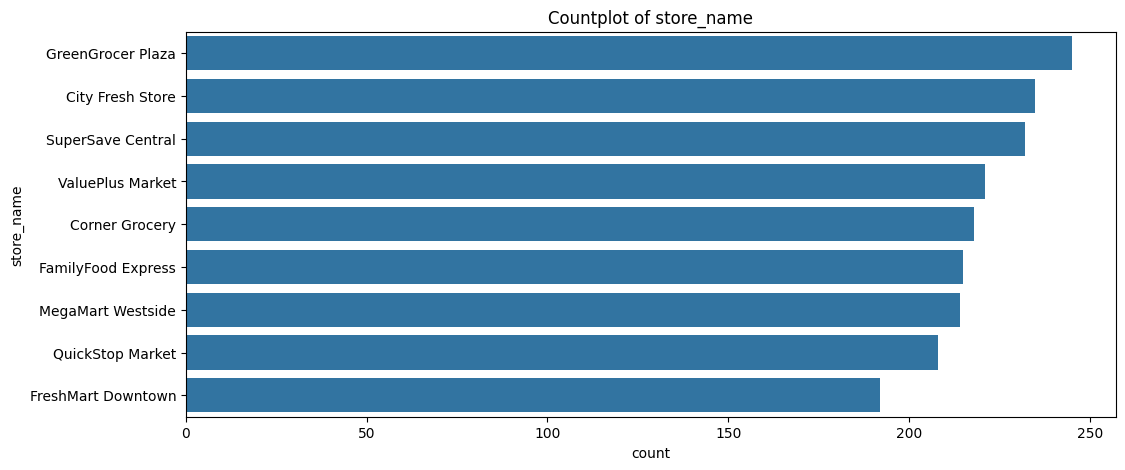

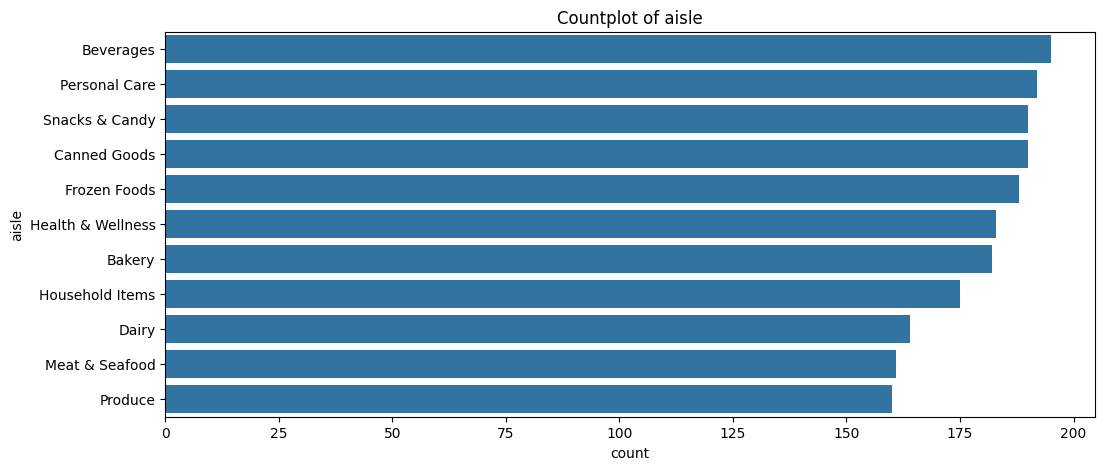

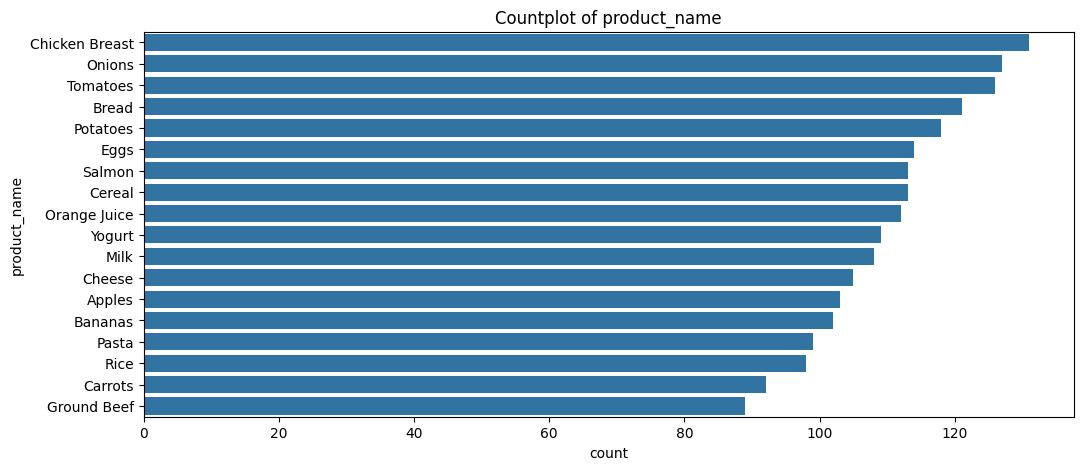

In [ ]:
categorical_cols = [
    'store_name',
    'aisle',
    'product_name'
]

for col in categorical_cols:

    plt.figure(figsize=(12,5))

    sns.countplot(
        y=data[col],
        order=data[col].value_counts().index
    )

    plt.title(f"Countplot of {col}")

    plt.show()

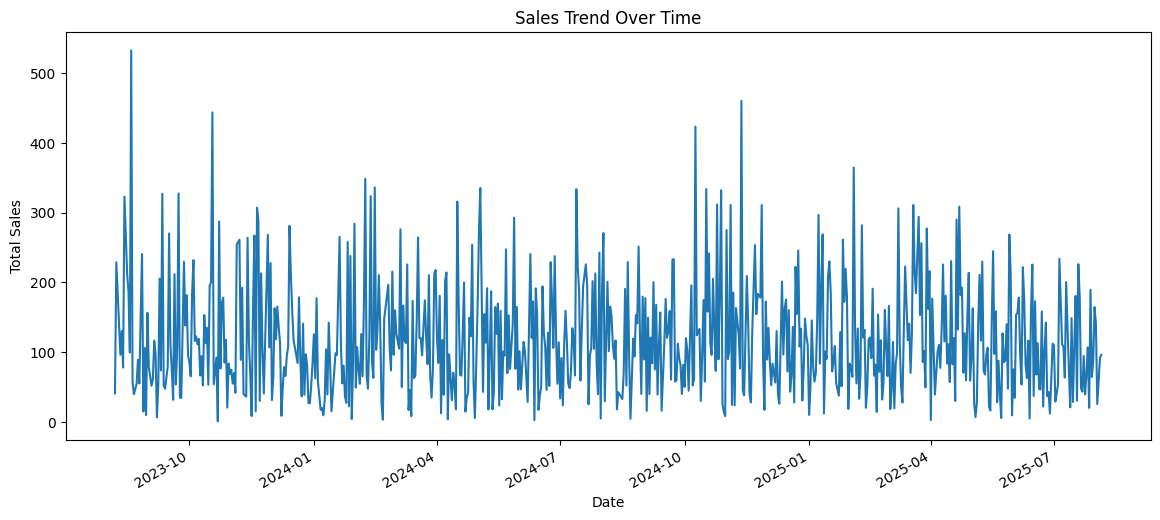

In [ ]:
sales_trend = data.groupby('transaction_date')['final_amount'].sum()

plt.figure(figsize=(14,6))

sales_trend.plot()

plt.title("Sales Trend Over Time")

plt.xlabel("Date")

plt.ylabel("Total Sales")

plt.show()

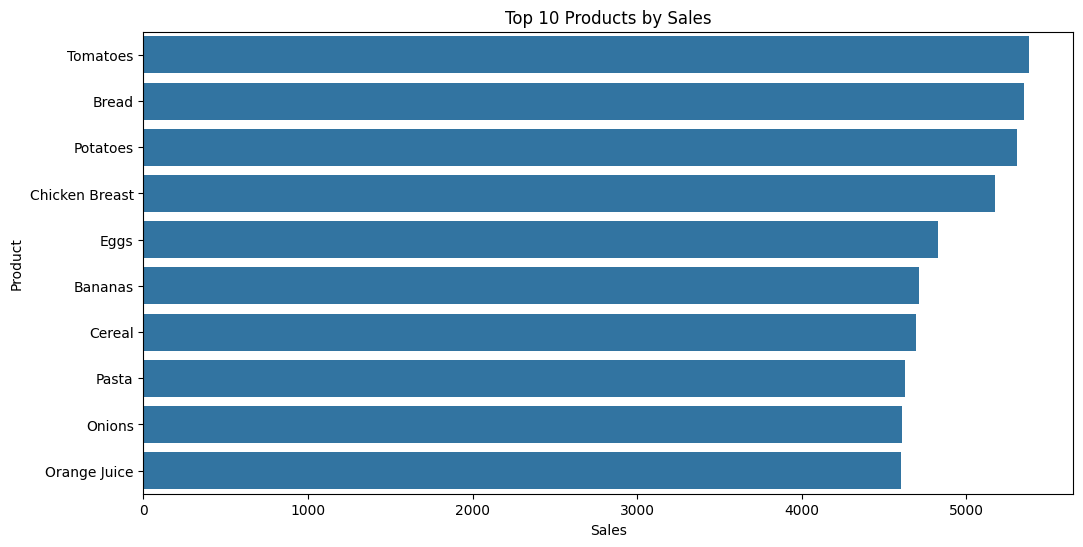

In [ ]:
top_products = (
    data.groupby('product_name')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales")

plt.ylabel("Product")

plt.show()

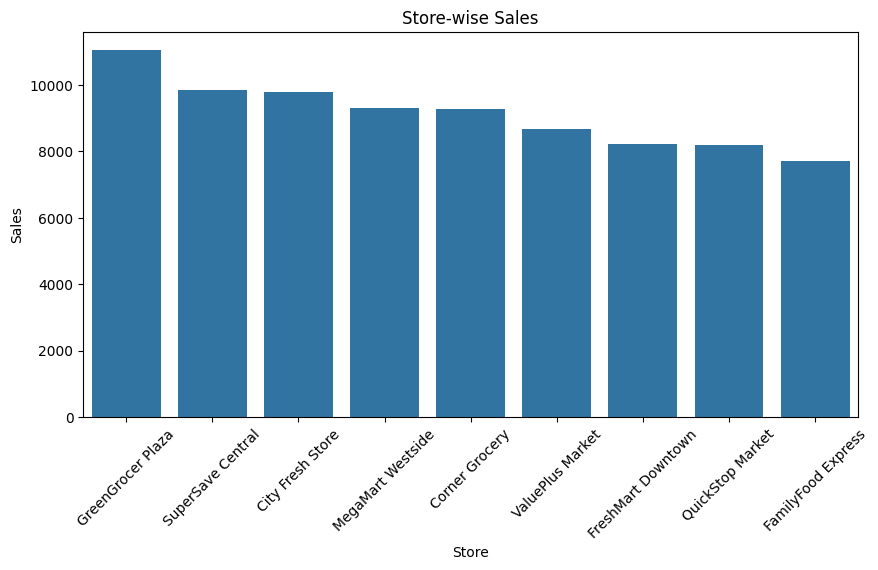

In [ ]:
top_stores = (
    data.groupby('store_name')['final_amount']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_stores.index,
    y=top_stores.values
)

plt.title("Store-wise Sales")

plt.xlabel("Store")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

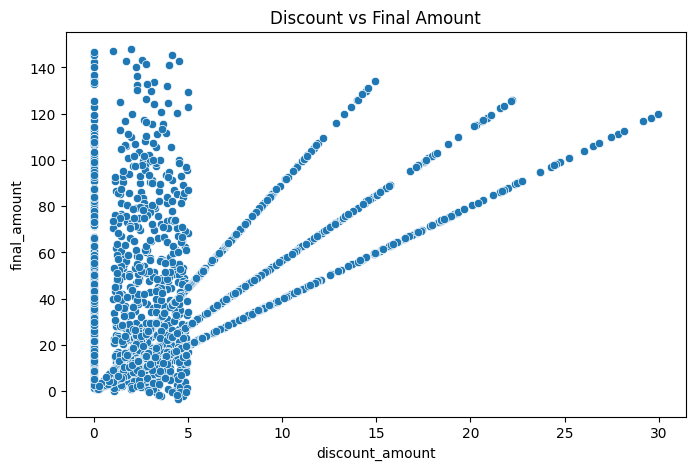

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='discount_amount',
    y='final_amount'
)

plt.title("Discount vs Final Amount")

plt.show()

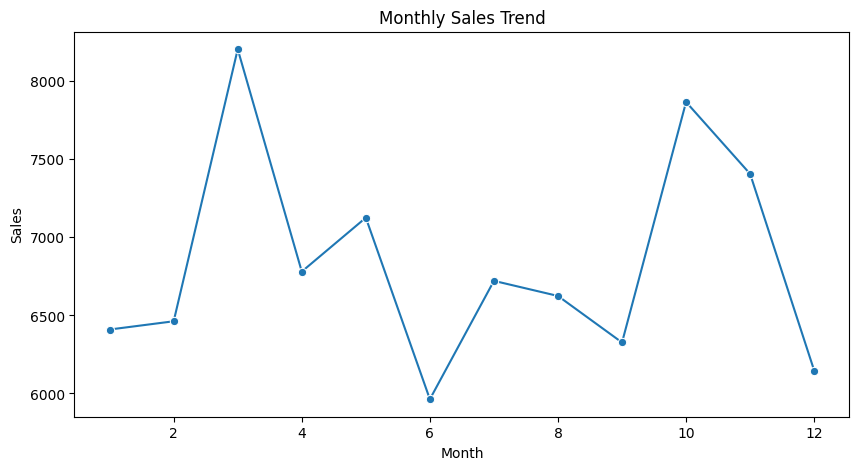

In [ ]:
data['month'] = data['transaction_date'].dt.month

monthly_sales = (
    data.groupby('month')['final_amount']
    .sum()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

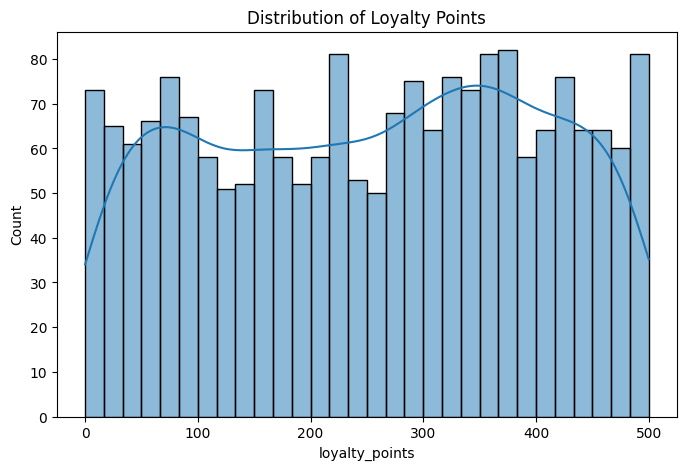

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data['loyalty_points'],
    bins=30,
    kde=True
)

plt.title("Distribution of Loyalty Points")

plt.show()

In [ ]:
for col in categorical_cols:
    print(f"\n{col}")
    print(data[col].value_counts().head())


store_name
store_name
GreenGrocer Plaza    245
City Fresh Store     235
SuperSave Central    232
ValuePlus Market     221
Corner Grocery       218
Name: count, dtype: int64

aisle
aisle
Beverages         195
Personal Care     192
Snacks & Candy    190
Canned Goods      190
Frozen Foods      188
Name: count, dtype: int64

product_name
product_name
Chicken Breast    131
Onions            127
Tomatoes          126
Bread             121
Potatoes          118
Name: count, dtype: int64


# KMeans

In [ ]:
features = [
    'quantity',
    'unit_price',
    'total_amount',
    'discount_amount',
    'final_amount',
    'loyalty_points'
]


x = data[features]

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
x_scaled[:5]

array([[-0.68245749, -0.95586749, -0.88496979, -0.90099145, -0.81365372,
         0.83476035],
       [-1.38734315, -1.62382791, -1.25829431, -0.21359502, -1.31940641,
        -0.98750122],
       [ 0.72731385, -0.96539277, -0.46794317, -0.08659802, -0.48957918,
         0.31411419],
       [ 0.02242818, -1.18923691, -0.83983951, -0.62482338, -0.80720906,
         1.60887899],
       [ 1.43219951, -0.81298826, -0.07433859, -0.59861765,  0.01126328,
        -1.59720528]])

elbow method

In [ ]:
wcss = []

for i in range(1,11):
  k_mean_alg = KMeans(
      n_clusters=i,
      random_state=42,
      n_init=10
  )

  k_mean_alg.fit(x_scaled)
  wcss.append(k_mean_alg.inertia_)

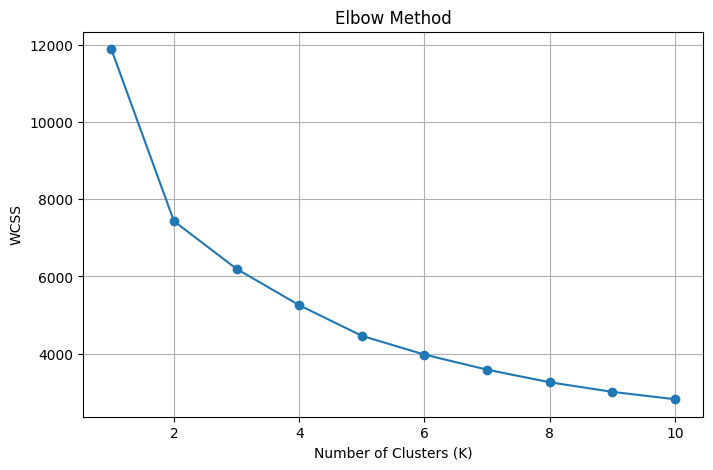

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [ ]:
# k = 2 and k = 5

k_mean_alg = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

data['cluster'] = k_mean_alg.fit_predict(x_scaled)

In [ ]:
print(data.groupby('cluster')[features].mean())


         quantity  unit_price  total_amount  discount_amount  final_amount  \
cluster                                                                      
0        1.667331    8.160080     12.517490         1.807669     10.709821   
1        4.246575   23.470320     98.673470        15.868219     82.805251   
2        4.219512   22.718432     94.220697         2.675157     91.545540   
3        4.098361    8.549529     34.148217         3.435656     30.712561   
4        1.857438   22.185145     39.851570         4.179401     35.672169   

         loyalty_points  
cluster                  
0            218.659363  
1            217.657534  
2            271.836237  
3            284.782787  
4            270.181818  


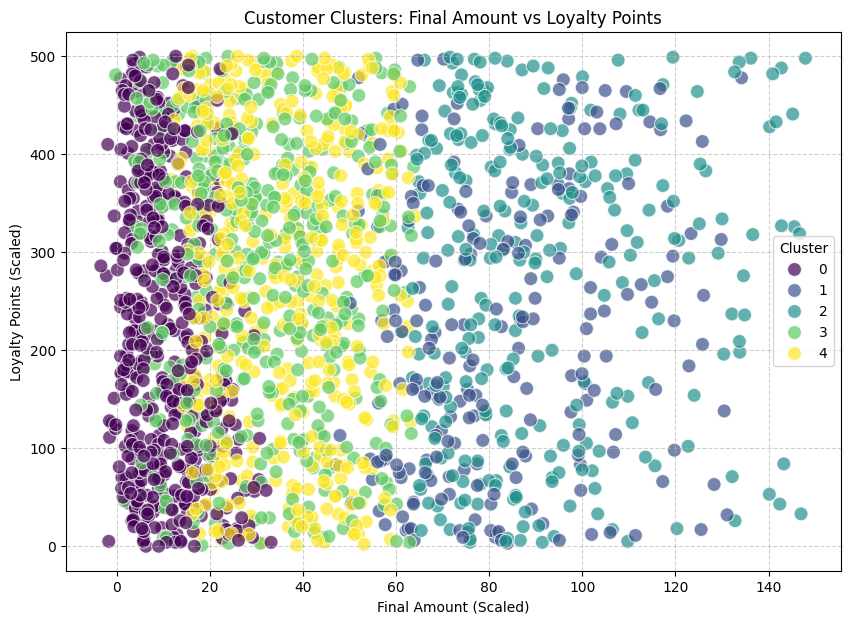

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x='final_amount',
    y='loyalty_points',
    hue='cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Customer Clusters: Final Amount vs Loyalty Points')
plt.xlabel('Final Amount (Scaled)')
plt.ylabel('Loyalty Points (Scaled)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

aggreagate

In [ ]:
customer_df = data.groupby('customer_id').agg(
   total_spend=('final_amount', 'sum'),
   avg_spend=('final_amount', 'mean'),
   total_quantity=('quantity', 'sum'),
   transaction_count=('product_name', 'count'), # Changed from 'transaction_id'
   total_loyalty_points=('loyalty_points', 'sum'),
   avg_discount=('discount_amount', 'mean')
).reset_index()

Now, let's apply KMeans clustering to the aggregated `customer_df` to segment customers based on their overall behavior. We'll use a similar set of features that represent customer value.

In [ ]:
customer_features = [
    'total_spend',
    'avg_spend',
    'total_quantity',
    'transaction_count',
    'total_loyalty_points',
    'avg_discount'
]

x_customer = customer_df[customer_features]

scaler_customer = StandardScaler()
x_scaled_customer = scaler_customer.fit_transform(x_customer)

# Using the same number of clusters (5) as for the transaction data
k_mean_alg_customer = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

customer_df['customer_cluster'] = k_mean_alg_customer.fit_predict(x_scaled_customer)

print(customer_df.groupby('customer_cluster')[customer_features].mean())

                  total_spend  avg_spend  total_quantity  transaction_count  \
customer_cluster                                                              
0                   21.259419  21.079528        2.199637           1.009074   
1                   91.733291  44.033819        6.310127           2.088608   
2                   78.607653  78.018826        4.244131           1.004695   
3                   25.139932  25.068302        2.617747           1.006826   
4                   83.979586  83.979586        4.241379           1.000000   

                  total_loyalty_points  avg_discount  
customer_cluster                                      
0                           125.464610      2.739864  
1                           548.462025      4.877885  
2                           226.690141     14.720728  
3                           379.505119      3.114480  
4                           271.482759      2.505931  


Now, let's visualize the customer clusters based on their `total_spend` and `total_loyalty_points`.

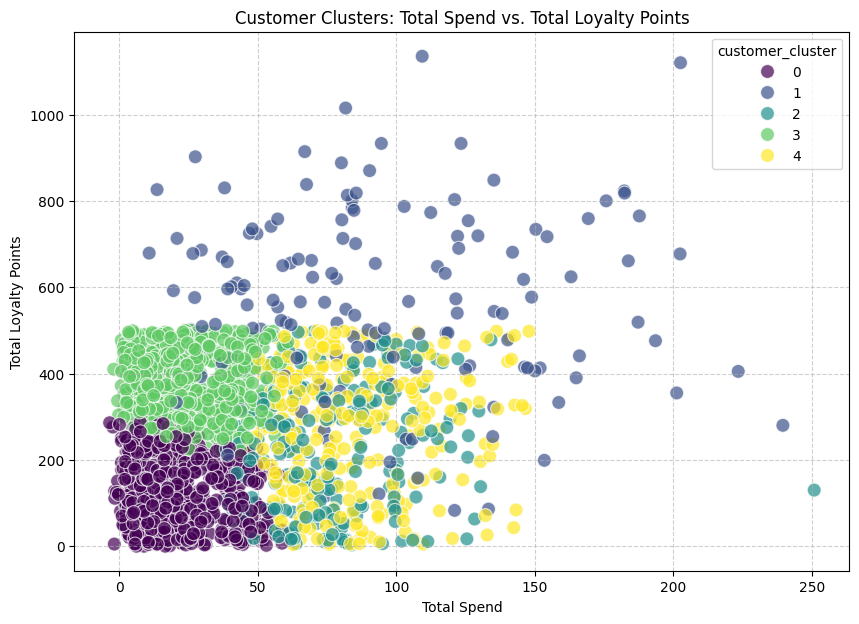

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='total_spend',
    y='total_loyalty_points',
    hue='customer_cluster',
    data=customer_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Customer Clusters: Total Spend vs. Total Loyalty Points')
plt.xlabel('Total Spend')
plt.ylabel('Total Loyalty Points')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# classification

In [ ]:
data.head(5)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points,month,cluster
0,2824,GreenGrocer Plaza,2023-08-26,Produce,Pasta,2,7.46,14.92,0.00,14.92,377,8,0
1,5506,ValuePlus Market,2024-02-13,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111,2,0
2,4657,ValuePlus Market,2023-11-23,Bakery,Onions,4,7.38,29.52,4.04,25.48,301,11,3
3,2679,SuperSave Central,2025-01-13,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490,1,3
4,9935,GreenGrocer Plaza,2023-10-13,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22,10,3


In [ ]:
print(data['cluster'].value_counts())

cluster
0    502
3    488
4    484
2    287
1    219
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
customer_data = data.groupby('customer_id').agg({
    'final_amount': ['sum', 'mean'],
    'quantity': 'sum',
    'discount_amount': 'sum',
    'loyalty_points': 'mean'
})

customer_data.columns = [
    'total_spent',
    'avg_transaction_value',
    'total_quantity',
    'total_discount',
    'avg_loyalty_points'
]

customer_data = customer_data.reset_index()

print("\nCustomer Data:")
print(customer_data.head())


Customer Data:
   customer_id  total_spent  avg_transaction_value  total_quantity  \
0         1006       109.75                 109.75               5   
1         1009        37.84                  37.84               2   
2         1018        51.91                  51.91               3   
3         1023        23.40                  23.40               1   
4         1040        43.58                  43.58               2   

   total_discount  avg_loyalty_points  
0            0.00                 5.0  
1            4.20               330.0  
2           12.98               478.0  
3            4.13               381.0  
4            3.40               101.0  


In [ ]:
customer_data.columns

Index(['customer_id', 'total_spent', 'avg_transaction_value', 'total_quantity',
       'total_discount', 'avg_loyalty_points'],
      dtype='object')

In [ ]:
features_class = customer_data[[
    'total_spent',
    'avg_transaction_value',
    'total_quantity',
    'total_discount',
    'avg_loyalty_points'
]]

In [ ]:
scaler_class = StandardScaler()

scaled_features_class = scaler_class.fit_transform(features_class)

elbow method

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

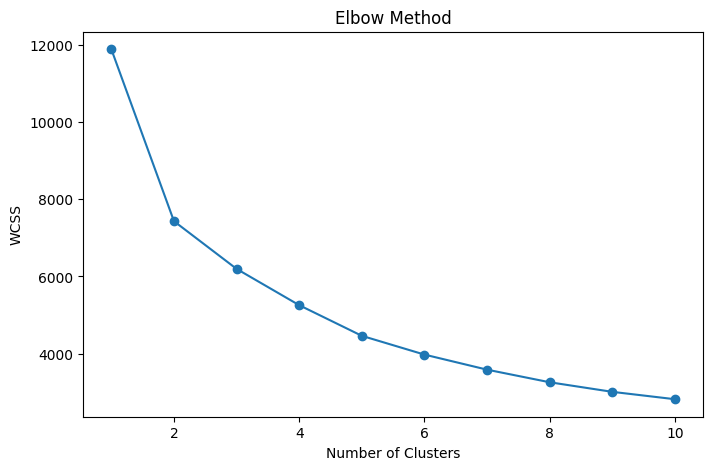

In [ ]:
wcss_class = []

for i in range(1,11):
  k_mean_class = KMeans(
      n_clusters=i,
      random_state=42,
      n_init=10
  )

  k_mean_class.fit(features_class)
  wcss_class.append(k_mean_class.inertia_)


  plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
k_mean_class = KMeans(n_clusters=3)
cluster_class = k_mean_class.fit_predict(features_class)

In [ ]:
print(pd.Series(cluster_class).value_counts())

0    627
2    607
1    564
Name: count, dtype: int64


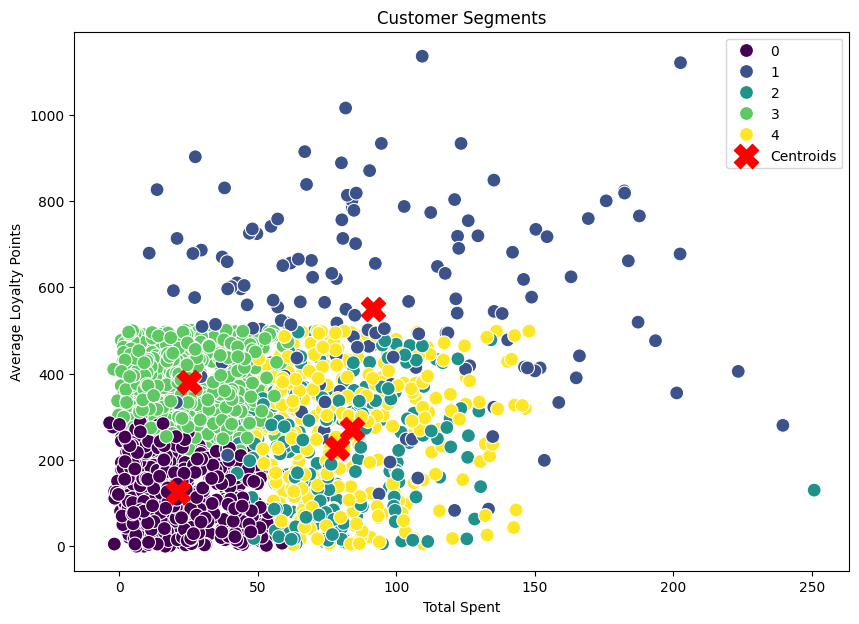

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=customer_df, # Use customer_df which has 'customer_cluster'
    x='total_spend', # Corrected column name in customer_df
    y='total_loyalty_points', # Corrected column name in customer_df
    hue='customer_cluster', # Corrected cluster column name
    palette='viridis',
    s=100
)

# Inverse transform centroids to the original scale for plotting
unscaled_centroids = scaler_customer.inverse_transform(k_mean_alg_customer.cluster_centers_)

plt.scatter(
    unscaled_centroids[:,0], # Corresponds to 'total_spend' (index 0 in customer_features)
    unscaled_centroids[:,4], # Corresponds to 'total_loyalty_points' (index 4 in customer_features)
    marker='X',
    s=300,
    c='red',
    label='Centroids'
)

plt.title("Customer Segments")
plt.xlabel("Total Spent")
plt.ylabel("Average Loyalty Points")
plt.legend()
plt.show()

classificaation

In [ ]:
X = customer_data[[
    'total_spent',
    'avg_transaction_value',
    'total_quantity',
    'total_discount',
    'avg_loyalty_points'
]]

y = cluster_class

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
y[:5]

array([1, 2, 0, 0, 1], dtype=int32)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [ ]:
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       133
           1       1.00      1.00      1.00       108
           2       1.00      1.00      1.00       119

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360



In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df = pd.read_csv("grocery_chain_data.csv")
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# ── 2. BUILD CUSTOMER-LEVEL FEATURES ─────────────────────────────────────────
# Aggregate all transactions per customer into one row
snapshot_date = df["transaction_date"].max()

features = df.groupby("customer_id").agg(
    total_spend        = ("final_amount",       "sum"),
    avg_order_value    = ("final_amount",       "mean"),
    num_transactions   = ("transaction_date",   "count"),
    total_quantity     = ("quantity",           "sum"),
    avg_discount       = ("discount_amount",    "mean"),
    total_loyalty_pts  = ("loyalty_points",     "sum"),
    unique_stores      = ("store_name",         "nunique"),
    unique_products    = ("product_name",       "nunique"),
    unique_aisles      = ("aisle",              "nunique"),
    last_purchase_date = ("transaction_date",   "max"),
    first_purchase_date= ("transaction_date",   "min"),
).reset_index()

# Days since last purchase (Recency)
features["days_since_last_purchase"] = (
    snapshot_date - features["last_purchase_date"]
).dt.days

# How long the customer has been active (in days)
features["customer_tenure_days"] = (
    features["last_purchase_date"] - features["first_purchase_date"]
).dt.days

# ── 3. DEFINE CHURN LABEL ─────────────────────────────────────────────────────
# A customer is "churned" if they haven't purchased in the last 90 days
CHURN_THRESHOLD_DAYS = 90
features["churned"] = (
    features["days_since_last_purchase"] > CHURN_THRESHOLD_DAYS
).astype(int)

print(f"Total customers : {len(features)}")
print(f"Churned         : {features['churned'].sum()} ({features['churned'].mean()*100:.1f}%)")
print(f"Active          : {(features['churned'] == 0).sum()}\n")

# ── 4. PREPARE FEATURES & LABELS ─────────────────────────────────────────────
feature_cols = [
    "total_spend", "avg_order_value", "num_transactions",
    "total_quantity", "avg_discount", "total_loyalty_pts",
    "unique_stores", "unique_products", "unique_aisles",
    "days_since_last_purchase", "customer_tenure_days",
]

X = features[feature_cols]
y = features["churned"]

# ── 5. TRAIN / TEST SPLIT ────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 6. TRAIN MODEL ───────────────────────────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

# ── 7. EVALUATE ──────────────────────────────────────────────────────────────
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("── Model Performance ───────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_proba):.4f}\n")

# ── 8. FEATURE IMPORTANCE ────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature":   feature_cols,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

print("── Top Churn Drivers ───────────────────────────")
print(importance_df.to_string(index=False))

# ── 9. PREDICT CHURN PROBABILITY FOR ALL CUSTOMERS ───────────────────────────
features["churn_probability"] = model.predict_proba(X)[:, 1]
features["churn_risk"] = pd.cut(
    features["churn_probability"],
    bins=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"],
)

# ── 10. EXPORT RESULTS ───────────────────────────────────────────────────────
output_cols = ["customer_id", "total_spend", "num_transactions",
               "days_since_last_purchase", "churn_probability", "churn_risk", "churned"]

results = features[output_cols].sort_values("churn_probability", ascending=False)
results.to_csv("churn_predictions.csv", index=False)

print("\n── High-Risk Customers (top 10) ────────────────")
print(results[results["churn_risk"] == "High"].head(10).to_string(index=False))
print("\n✅ Saved full results to churn_predictions.csv")

Total customers : 1798
Churned         : 1570 (87.3%)
Active          : 228

── Model Performance ───────────────────────────
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00        46
     Churned       1.00      1.00      1.00       314

    accuracy                           1.00       360
   macro avg       1.00      1.00      1.00       360
weighted avg       1.00      1.00      1.00       360

ROC-AUC Score : 1.0000

── Top Churn Drivers ───────────────────────────
                 feature  importance
days_since_last_purchase    0.911032
            avg_discount    0.020759
         avg_order_value    0.019126
             total_spend    0.014140
       total_loyalty_pts    0.013944
    customer_tenure_days    0.011142
          total_quantity    0.007107
        num_transactions    0.000864
           unique_stores    0.000791
         unique_products    0.000719
           unique_aisles    0.000376

── High-Risk Customers (top 1